# 03 - Yerkes-Dodson validation

Builds the trial-level analysis table used by this notebook and the next, then
asks whether the decoded arousal index reproduces the inverted-U relationship
between arousal and performance.

Two arousal signals are compared:

- **New**: the peripheral decoder from notebook 01, rescaled per subject
  against its training distribution.
- **Old**: the `FB-HB-0-1-nrm` channel, the normalised feedback signal driven
  by the Faller et al. EEG decoder. Note this channel is min-max scaled *within
  each trial* (see `METHODS.md`), so it carries trial shape rather than
  trial-to-trial level.

In [1]:
import sys
sys.path.insert(0, "..")   # or: pip install -e .. to import `arousal` directly

import pickle

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import numpy as np
import pandas as pd

from arousal import config as cfg
from arousal import data as D
from arousal import yerkes as Y
from arousal.plotting import (BLUE, FS_AN, FS_AX, FS_PAN, FS_TK, RED, fmt_p,
                              panel, stars, tidy)

CACHE = cfg.DATA / "trial_table.pkl"

## Build the trial table

One row per closed-loop trial: decoded arousal trace, raw physiological traces,
flight time, condition, difficulty and the subject's baseline physiology.

In [2]:
if CACHE.exists():
    df = pd.read_pickle(CACHE)
    print(f"loaded cached trial table: {len(df)} trials")
else:
    with open(cfg.RESULTS / "results_online_simple_physio.pkl", "rb") as f:
        arousal_results = pickle.load(f)["final_results"]

    ring_online = D.load_ring_epochs_online()
    trials = D.build_trial_table(arousal_results, ring_online=ring_online)
    baselines = D.baseline_features(ring_online)
    df = D.attach_baselines(trials, baselines)
    df["arousal_old_mean"] = df["old_arousal"].apply(np.mean)
    df.to_pickle(CACHE)
    print(f"built trial table: {len(df)} trials")

print(f"  subjects   : {df['subject'].nunique()}")
print(f"  conditions : {df['condition'].value_counts().sort_index().to_dict()}")
print(f"  difficulty : {df['difficulty'].value_counts().to_dict()}")

built trial table: 352 trials
  subjects   : 16
  conditions : {1: 115, 2: 121, 3: 116}
  difficulty : {0: 179, 1: 173}


## Fit the models

`performance ~ difficulty * (arousal + arousal^2) + condition`, with a random
intercept per subject, fitted by maximum likelihood so AIC is comparable across
fixed-effect structures.

In [3]:
models = {
    "new_quad": Y.fit_yd_model(df, "arousal"),
    "new_lin": Y.fit_yd_model(df, "arousal", Y.FORMULA_LINEAR),
    "old_quad": Y.fit_yd_model(df, "arousal_old_mean"),
    "old_lin": Y.fit_yd_model(df, "arousal_old_mean", Y.FORMULA_LINEAR),
}

for label, key in [("Peripheral", "new_quad"), ("EEG feedback", "old_quad")]:
    m = models[key]
    pv = Y.quadratic_pvalues(m)
    opt0, ci0 = Y.optimum_with_ci(m, 0)
    opt1, ci1 = Y.optimum_with_ci(m, 1)
    print(f"\n{label}")
    print(f"  linear term      p = {m.pvalues['arousal']:.2e}")
    print(f"  quadratic (easy) p = {pv[0]:.2e}")
    print(f"  quadratic (hard) p = {pv[1]:.2e}")
    print(f"  optimum easy = {opt0:5.1f}  [{ci0[0]:.1f}, {ci0[1]:.1f}]")
    print(f"  optimum hard = {opt1:5.1f}  [{ci1[0]:.1f}, {ci1[1]:.1f}]")
    print(Y.coefficient_table(m).to_string(index=False, float_format="%.4g"))


Peripheral
  linear term      p = 5.69e-09
  quadratic (easy) p = 4.69e-05
  quadratic (hard) p = 1.10e-03
  optimum easy =  52.2  [41.4, 62.9]
  optimum hard =  50.8  [37.6, 64.0]
                              term   coef     se  ci_lo  ci_hi         p
                           arousal  267.2  45.87  177.3  357.1 5.687e-09
                   I(arousal ** 2) -2.562 0.6293 -3.795 -1.328 4.688e-05
        C(difficulty)[T.1]:arousal -41.64  58.15 -155.6  72.34     0.474
C(difficulty)[T.1]:I(arousal ** 2) 0.3406  0.844 -1.314  1.995    0.6866

EEG feedback
  linear term      p = 2.38e-02
  quadratic (easy) p = 9.66e-02
  quadratic (hard) p = 4.10e-01
  optimum easy =  61.9  [37.1, 86.7]
  optimum hard =  76.0  [-14.3, 166.2]
                              term   coef     se  ci_lo  ci_hi       p
                           arousal  160.7  71.06  21.39    300 0.02376
                   I(arousal ** 2) -1.298 0.7815  -2.83 0.2334 0.09665
        C(difficulty)[T.1]:arousal  -61.4  91.91 -241.

In [4]:
aic = {k: m.aic for k, m in models.items()}
best = min(aic.values())
print("model comparison (dAIC vs best):")
for k, v in sorted(aic.items(), key=lambda kv: kv[1]):
    print(f"  {k:<10} AIC = {v:9.1f}   dAIC = {v - best:6.1f}")

model comparison (dAIC vs best):
  new_quad   AIC =    6704.5   dAIC =    0.0
  new_lin    AIC =    6723.1   dAIC =   18.6
  old_lin    AIC =    6749.0   dAIC =   44.5
  old_quad   AIC =    6749.8   dAIC =   45.3


## Figure 2

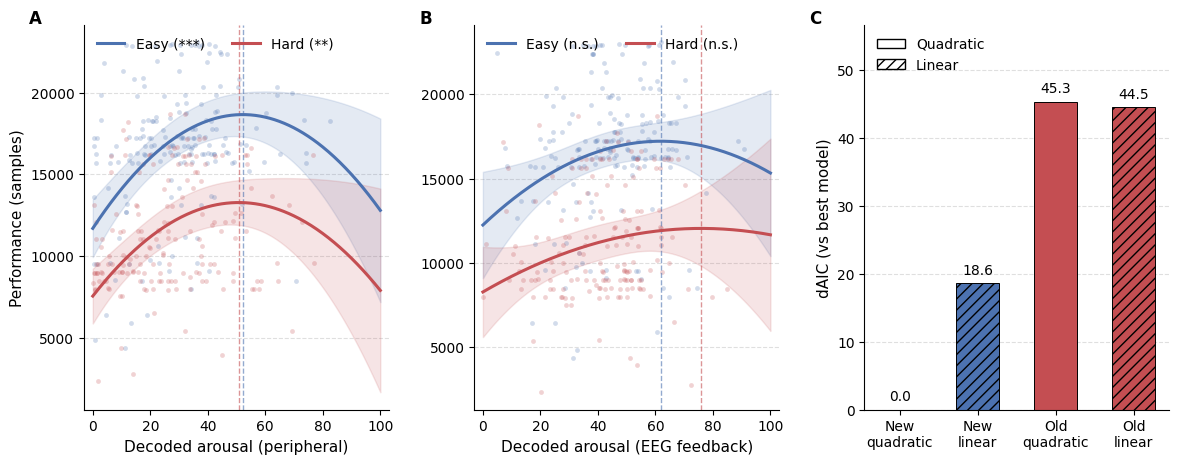

In [5]:
def plot_yd(ax, model, frame, arousal_col, grid, letter, xlabel):
    sig = Y.quadratic_pvalues(model)
    preds = Y.predict_curve(model, grid)
    colors = {0: BLUE, 1: RED}
    labels = {0: f"Easy ({stars(sig[0])})", 1: f"Hard ({stars(sig[1])})"}

    for d in (0, 1):
        sub = frame[frame["difficulty"] == d]
        ax.scatter(sub[arousal_col], sub["performance"], color=colors[d],
                   alpha=0.25, s=12, linewidths=0, zorder=2)
    for d in (0, 1):
        p = preds[d]
        ax.plot(grid, p["mean"], color=colors[d], lw=2.2, label=labels[d], zorder=3)
        ax.fill_between(grid, p["ci_lo"], p["ci_hi"], color=colors[d],
                        alpha=0.15, zorder=1)
        opt, _ = Y.optimum_with_ci(model, d)
        if 0 <= opt <= 100:
            ax.axvline(opt, color=colors[d], ls="--", lw=1.0, alpha=0.6, zorder=2)

    ax.set_xlabel(xlabel, fontsize=FS_AX)
    ax.set_ylabel("Performance (samples)", fontsize=FS_AX)
    ax.set_xlim(-3, 103)
    tidy(ax)
    panel(ax, letter, x=-0.18)
    ax.legend(fontsize=FS_AN, frameon=False, loc="upper left", ncol=2)


fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.28)
grid = np.linspace(0, 100, 300)

ax_a = fig.add_subplot(gs[0])
plot_yd(ax_a, models["new_quad"], df, "arousal", grid, "A",
        "Decoded arousal (peripheral)")

ax_b = fig.add_subplot(gs[1])
plot_yd(ax_b, models["old_quad"], df, "arousal_old_mean", grid, "B",
        "Decoded arousal (EEG feedback)")
ax_b.set_ylabel("")

# --- C: model comparison ------------------------------------------------------
ax_c = fig.add_subplot(gs[2])
order = ["new_quad", "new_lin", "old_quad", "old_lin"]
names = ["New\nquadratic", "New\nlinear", "Old\nquadratic", "Old\nlinear"]
deltas = [aic[k] - best for k in order]
bars = ax_c.bar(range(4), deltas, color=[BLUE, BLUE, RED, RED],
                edgecolor="black", linewidth=0.7, width=0.55, zorder=2)
for bar, hatch in zip(bars, ["", "///", "", "///"]):
    bar.set_hatch(hatch)
for bar, val in zip(bars, deltas):
    ax_c.text(bar.get_x() + bar.get_width() / 2, val + max(deltas) * 0.02,
              f"{val:.1f}", ha="center", va="bottom", fontsize=FS_AN)

ax_c.set_xticks(range(4))
ax_c.set_xticklabels(names, fontsize=8)
ax_c.set_ylabel("dAIC (vs best model)", fontsize=FS_AX)
ax_c.set_ylim(0, max(deltas) * 1.25)
tidy(ax_c)
panel(ax_c, "C", x=-0.18)
ax_c.legend(handles=[
    mpl.patches.Patch(facecolor="white", edgecolor="black", label="Quadratic"),
    mpl.patches.Patch(facecolor="white", edgecolor="black", hatch="///",
                      label="Linear")],
    fontsize=FS_AN, frameon=False, loc="upper left")

cfg.FIGURES.mkdir(exist_ok=True)
plt.savefig(cfg.FIGURES / "figure_2.png", dpi=300, bbox_inches="tight")
plt.show()

## External validation

Correlation between the decoded arousal index and the raw physiological
channels, computed within trial over time and then averaged across trials.
Note the raw channels are min-max scaled per trial, so these are correlations
of shape within a trial, not of absolute level.

In [6]:
def within_trial_corr(frame, column):
    rs = []
    for _, row in frame.iterrows():
        a, b = row["new_arousal"], row[column]
        n = min(len(a), len(b))
        if n < 100 or np.std(a[:n]) == 0 or np.std(b[:n]) == 0:
            continue
        rs.append(np.corrcoef(a[:n], b[:n])[0, 1])
    return np.array(rs)


for column, label in [("hr_signal", "HR"), ("hrv_signal", "HRV-pNN35"),
                      ("eda_phasic", "EDA-phasic"), ("eda_tonic", "EDA-tonic"),
                      ("pupil_signal", "Pupil"), ("old_arousal", "EEG feedback")]:
    rs = within_trial_corr(df, column)
    print(f"  {label:<14} mean r = {rs.mean():+.3f}  (n = {len(rs)} trials)")

  HR             mean r = +0.449  (n = 352 trials)
  HRV-pNN35      mean r = -0.213  (n = 335 trials)
  EDA-phasic     mean r = +0.312  (n = 352 trials)
  EDA-tonic      mean r = +0.212  (n = 352 trials)
  Pupil          mean r = +0.187  (n = 352 trials)
  EEG feedback   mean r = +0.404  (n = 352 trials)


## Figure 3: baseline physiology modulates the curve

Adding `HRV_z` and `gamma_z` interactions with the linear and quadratic arousal
terms. Curves are drawn for the hard course at the reference condition.

In [7]:
interactions = {f: Y.fit_interaction_model(df, f) for f in ("hrv", "gamma")}
for f, m in interactions.items():
    term = f"I(arousal ** 2):{f}_z"
    print(f"  arousal^2 x {f:<6} beta = {m.params[term]:+.4g}, "
          f"p = {m.pvalues[term]:.4f}")

  arousal^2 x hrv    beta = +1.099, p = 0.0174
  arousal^2 x gamma  beta = -1.207, p = 0.0362


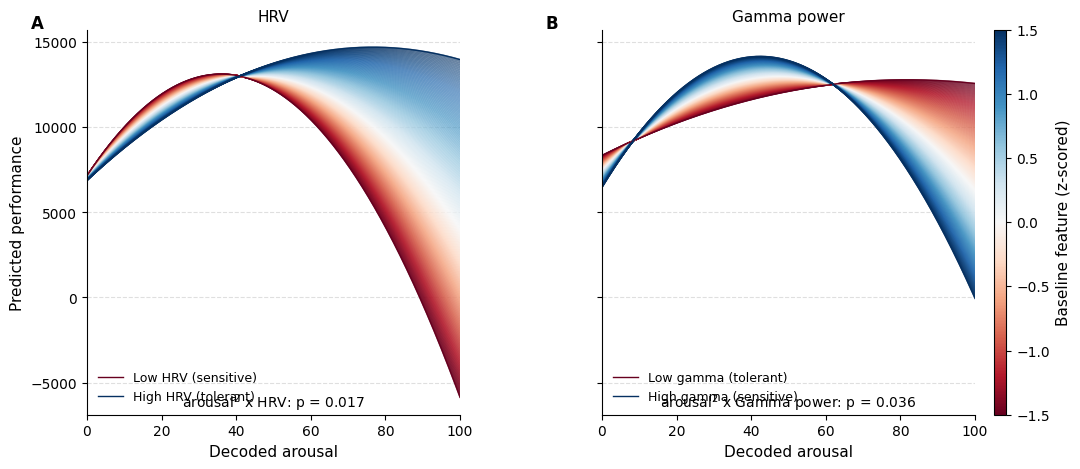

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.38)

grid = np.linspace(0, 100, 1200)
z_slices = np.linspace(-1.5, 1.5, 200)
norm = mpl.colors.Normalize(vmin=-1.5, vmax=1.5)
cmap = plt.get_cmap("RdBu")

extremes = {
    "hrv": {-1.5: "Low HRV (sensitive)", 1.5: "High HRV (tolerant)"},
    "gamma": {-1.5: "Low gamma (tolerant)", 1.5: "High gamma (sensitive)"},
}
titles = {"hrv": "HRV", "gamma": "Gamma power"}

for ax, (feature, model) in zip(axes, interactions.items()):
    for z in z_slices:
        pred = model.predict(pd.DataFrame({
            "arousal": grid, "difficulty": 1, "condition": 1,
            f"{feature}_z": z}))
        ax.plot(grid, pred, color=cmap(norm(z)), lw=1.2, alpha=0.6)
    for z, label in extremes[feature].items():
        pred = model.predict(pd.DataFrame({
            "arousal": grid, "difficulty": 1, "condition": 1,
            f"{feature}_z": z}))
        ax.plot(grid, pred, color=cmap(norm(z)), lw=1, label=label)

    term = f"I(arousal ** 2):{feature}_z"
    ax.set_xlabel("Decoded arousal", fontsize=FS_AX)
    ax.set_title(titles[feature], fontsize=FS_AX, pad=6)
    ax.set_xlim(0, 100)
    tidy(ax)
    ax.legend(fontsize=9, frameon=False, loc="lower left")
    ax.text(0.5, 0.02, f"arousal$^2$ x {titles[feature]}: "
            f"{fmt_p(model.pvalues[term])}", transform=ax.transAxes,
            ha="center", fontsize=10)

axes[0].set_ylabel("Predicted performance", fontsize=FS_AX)
axes[1].set_ylabel("")
axes[1].tick_params(labelleft=False)
lims = [ax.get_ylim() for ax in axes]
for ax in axes:
    ax.set_ylim(min(l[0] for l in lims), max(l[1] for l in lims))
panel(axes[0], "A", x=-0.15)
panel(axes[1], "B", x=-0.15)

cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap="RdBu", norm=norm), ax=axes,
                    orientation="vertical", pad=0.02, fraction=0.025, aspect=30)
cbar.set_label("Baseline feature (z-scored)", fontsize=FS_AX)
cbar.ax.tick_params(labelsize=FS_TK)

plt.savefig(cfg.FIGURES / "figure_3.png", dpi=300, bbox_inches="tight")
plt.show()

## Feedback condition and the arousal trajectory

Trial-level summaries of the decoded arousal, compared across the three
closed-loop conditions.

In [9]:
from scipy.stats import f_oneway

hard = df[df["difficulty"] == 1]
for label, fn in [("mean arousal", np.mean), ("peak arousal", np.max)]:
    groups = [hard.loc[hard["condition"] == c, "new_arousal"].apply(fn).to_numpy()
              for c in (1, 2, 3)]
    stat, p = f_oneway(*groups)
    means = "  ".join(f"{cfg.CONDITIONS[c]}={g.mean():.1f}"
                      for c, g in zip((1, 2, 3), groups))
    print(f"  {label:<14} F = {stat:5.2f}, p = {p:.3f}   {means}")

  mean arousal   F =  0.09, p = 0.914   silence=25.7  half=26.5  bci=27.2
  peak arousal   F =  0.26, p = 0.775   silence=74.8  half=71.8  bci=75.5
